In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel("heart_disease.xlsx", sheet_name="Heart_disease")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [4]:
 df.shape

(908, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df.drop_duplicates(inplace=True,ignore_index=True) 
df.head()               

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [9]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [10]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [11]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

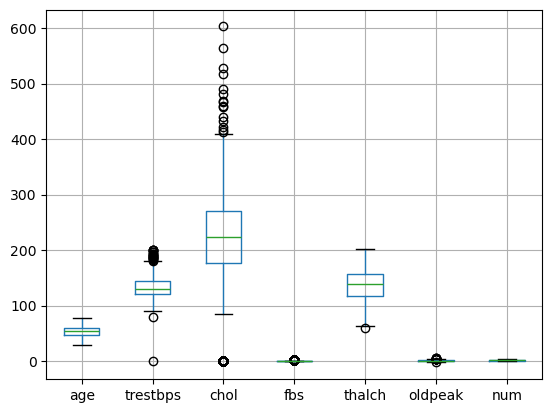

In [12]:
import matplotlib.pyplot as plt
df.boxplot()
plt.show()

In [13]:
#### outlier capping
for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])

<Figure size 1200x600 with 0 Axes>

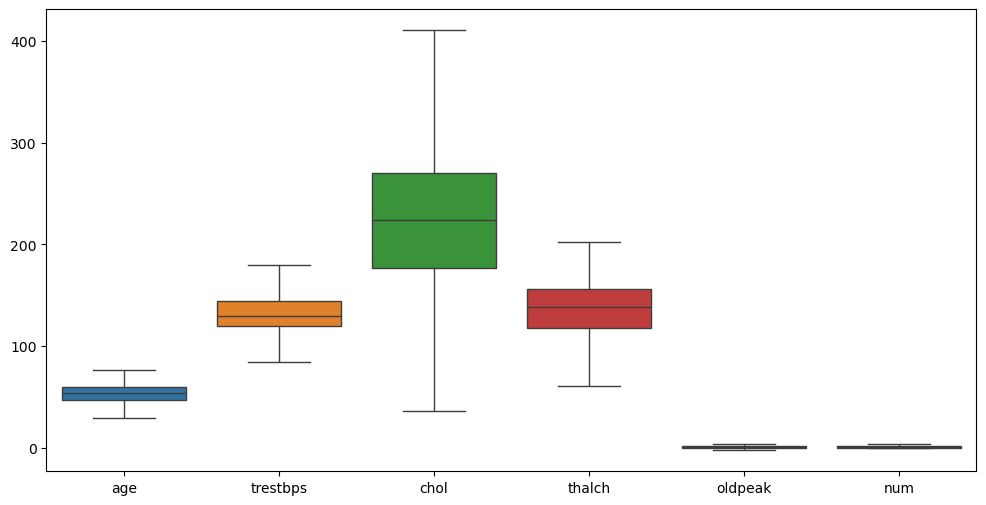

In [15]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=['int64','float64']))
plt.show()

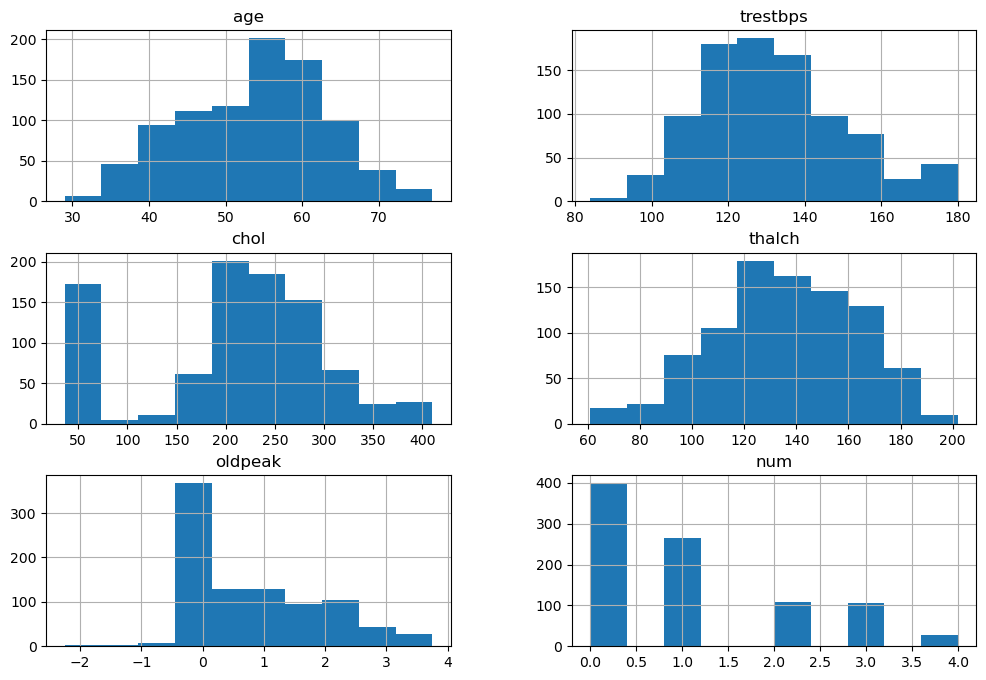

In [16]:
df[num_cols].hist(figsize=(12,8))
plt.show()

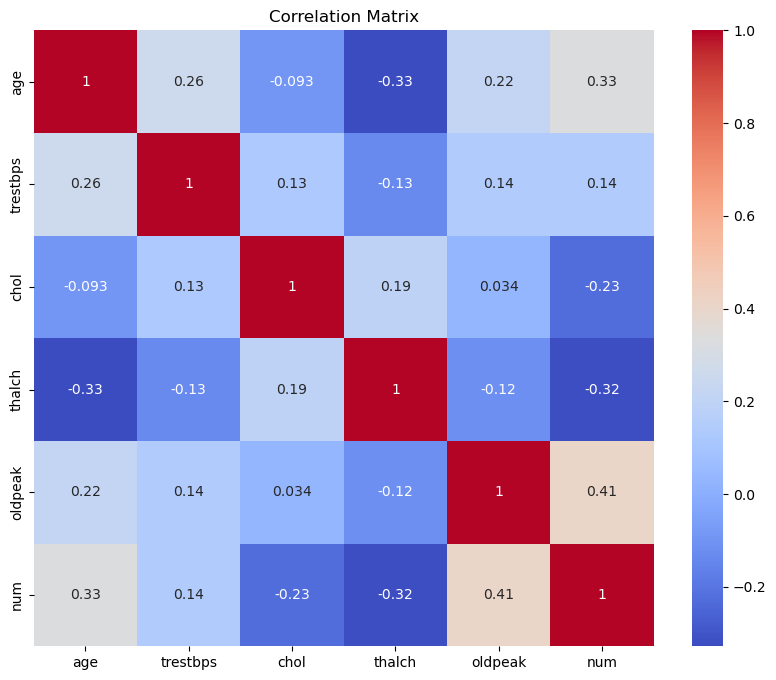

In [17]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'bool':
        df[col] = df[col].astype(str)   # ✅ FIX
        df[col] = le.fit_transform(df[col])

In [19]:
df = pd.get_dummies(df, drop_first=True)

In [20]:
from sklearn.preprocessing import StandardScaler

# separate features and target
X = df.drop("num", axis=1)
y = df["num"]

# select only numerical columns
num_cols = X.select_dtypes(include=['int64','float64']).columns

# apply scaling
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [21]:
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

In [22]:
from sklearn.model_selection import train_test_split

# separate features and target
X = df.drop("num", axis=1)
y = df["num"]

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # good practice for classification
)

In [23]:
from sklearn.tree import DecisionTreeClassifier

# create model
dt_model = DecisionTreeClassifier(
    criterion="gini",     # or "entropy"
    max_depth=5,          # prevents overfitting
    random_state=42
)

# train model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [24]:
y_pred = dt_model.predict(X_test)

# for ROC-AUC
y_prob = dt_model.predict_proba(X_test)[:, 1]

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.72      0.75      0.74        80
         1.0       0.39      0.51      0.44        53
         2.0       0.33      0.09      0.14        22
         3.0       0.26      0.29      0.27        21
         4.0       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.34      0.33      0.32       182
weighted avg       0.50      0.52      0.50       182



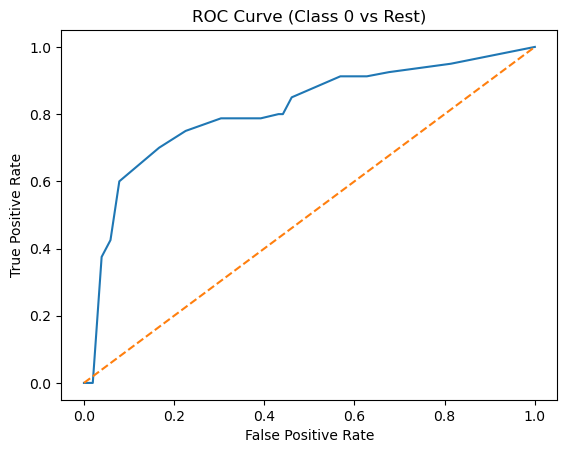

In [26]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_prob = dt_model.predict_proba(X_test)

 
y_test_binary = (y_test == 0).astype(int)


y_prob_binary = y_prob[:, 0]

# ROC
fpr, tpr, _ = roc_curve(y_test_binary, y_prob_binary)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve (Class 0 vs Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

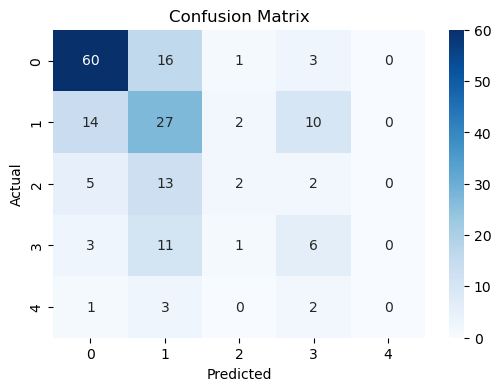

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3,5,7,10],
    "min_samples_split": [2,5,10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [32]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))

Optimized Accuracy: 0.5


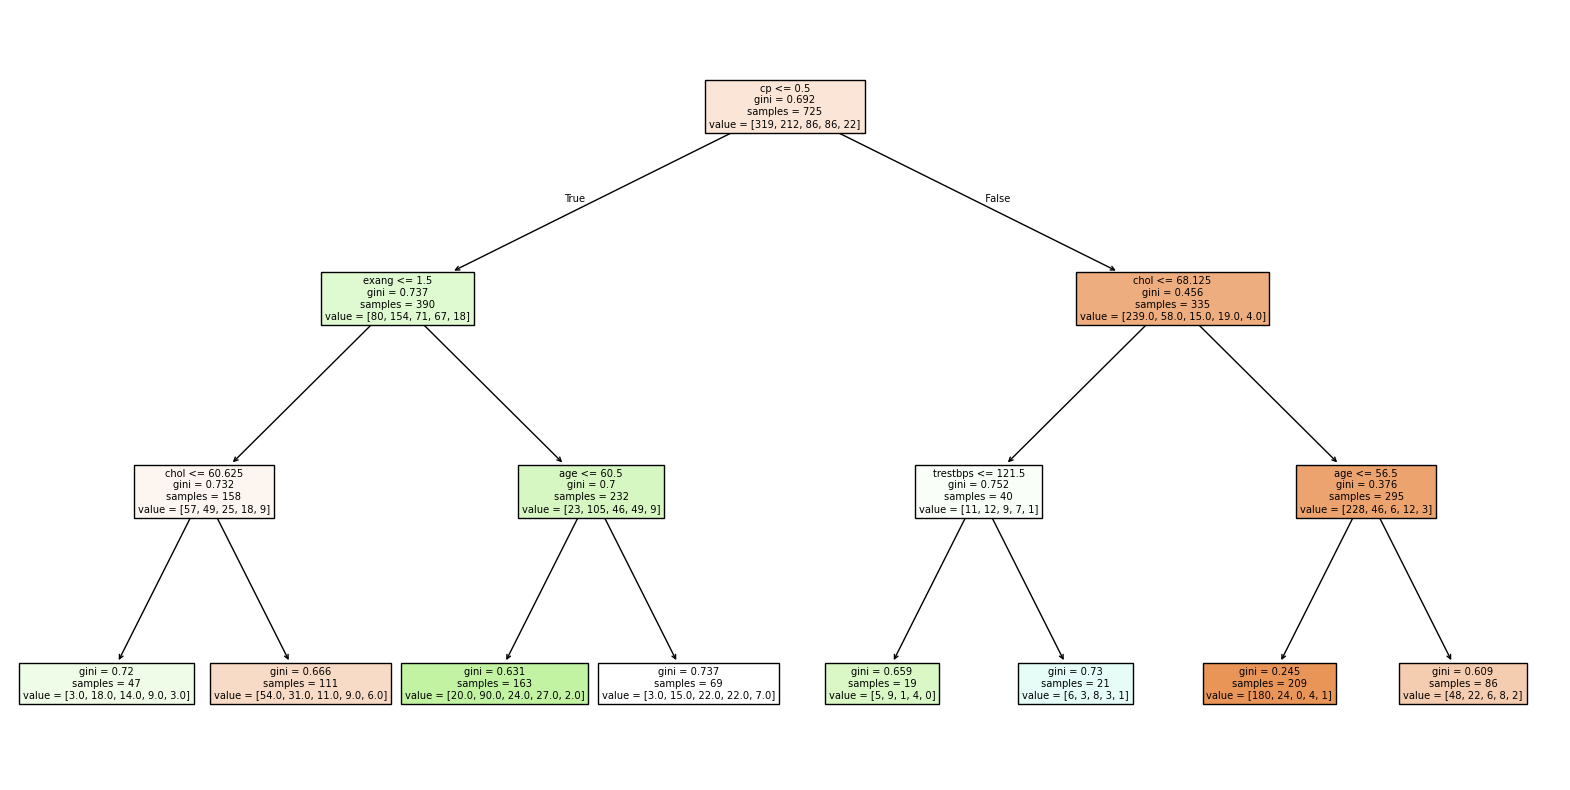

In [33]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    feature_names=X.columns,
    filled=True
)

plt.show()

In [34]:


# predictions
y_pred = best_model.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.5

Classification Report:
               precision    recall  f1-score   support

         0.0       0.67      0.84      0.74        80
         1.0       0.39      0.42      0.40        53
         2.0       0.08      0.09      0.09        22
         3.0       0.00      0.00      0.00        21
         4.0       0.00      0.00      0.00         6

    accuracy                           0.50       182
   macro avg       0.23      0.27      0.25       182
weighted avg       0.42      0.50      0.45       182


Confusion Matrix:
 [[67 10  3  0  0]
 [19 22 12  0  0]
 [ 7 13  2  0  0]
 [ 5 10  6  0  0]
 [ 2  2  2  0  0]]


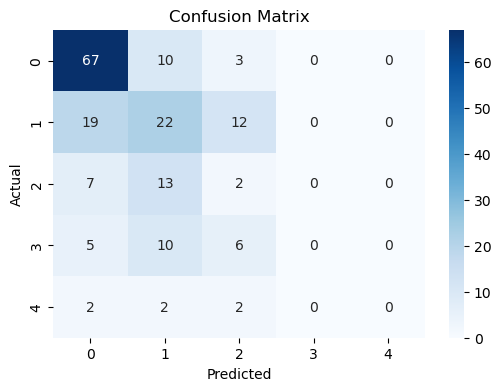

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Interview Questions: